In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

G = nx.karate_club_graph()

print("Graph loaded successfully")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Graph type:", type(G))
print("Is directed:", G.is_directed())

Graph loaded successfully
Nodes: 34
Edges: 78
Graph type: <class 'networkx.classes.graph.Graph'>
Is directed: False


In [ ]:
components = list(nx.connected_components(G))
component_sizes = sorted([len(c) for c in components], reverse=True)

print("Number of connected components:", len(components))
print("Component sizes:", component_sizes)
print("Largest connected component size:", component_sizes[0])

components_df = pd.DataFrame({
    "component": range(1, len(component_sizes) + 1),
    "size": component_sizes
})

components_df

Number of connected components: 1
Component sizes: [34]
Largest connected component size: 34


,component,size
0,1,34


In [ ]:
articulation_points = list(nx.articulation_points(G))
bridges = list(nx.bridges(G))

print("Articulation points:", articulation_points)
print("Number of articulation points:", len(articulation_points))
print()
print("Bridges:", bridges)
print("Number of bridges:", len(bridges))

Articulation points: [0]
Number of articulation points: 1

Bridges: [(0, 11)]
Number of bridges: 1


In [ ]:
betweenness = nx.betweenness_centrality(G, weight=None)

centrality_df = pd.DataFrame({
    "node": list(G.nodes()),
    "club": [G.nodes[n]["club"] for n in G.nodes()],
    "degree": [G.degree(n) for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()]
}).sort_values("betweenness", ascending=False)

centrality_df.head(10)

,node,club,degree,betweenness
0,0,Mr. Hi,16,0.437635
33,33,Officer,17,0.304075
32,32,Officer,12,0.145247
2,2,Mr. Hi,10,0.143657
31,31,Officer,6,0.138276
8,8,Mr. Hi,5,0.055927
1,1,Mr. Hi,9,0.053937
13,13,Mr. Hi,5,0.045863
19,19,Mr. Hi,3,0.032475
5,5,Mr. Hi,4,0.029987


In [ ]:

boundary_candidates = centrality_df[~centrality_df["node"].isin([0, 33])]
critical_node = int(boundary_candidates.iloc[0]["node"])

print("Selected critical boundary node:", critical_node)
print("Club:", G.nodes[critical_node]["club"])
print("Degree:", G.degree(critical_node))
print("Betweenness:", betweenness[critical_node])

Selected critical boundary node: 32
Club: Officer
Degree: 12
Betweenness: 0.145247113997114




We remove the selected boundary node and compare the number of components and the size of the largest connected component before and after removal.


In [ ]:
def connectivity_summary(graph):
    comps = list(nx.connected_components(graph))
    sizes = sorted([len(c) for c in comps], reverse=True)
    return {
        "nodes": graph.number_of_nodes(),
        "edges": graph.number_of_edges(),
        "components": len(comps),
        "largest_component_size": sizes[0],
        "component_sizes": sizes
    }

baseline = connectivity_summary(G)

G_node_removed = G.copy()
G_node_removed.remove_node(critical_node)

after_node = connectivity_summary(G_node_removed)

node_removal_df = pd.DataFrame([
    {"case": "Original graph", **baseline},
    {"case": f"After removing node {critical_node}", **after_node}
])

node_removal_df

,case,nodes,edges,components,largest_component_size,component_sizes
0,Original graph,34,78,1,34,[34]
1,After removing node 32,33,66,1,33,[33]




If the graph has bridges, we remove one bridge because a bridge is structurally critical by definition.  
If the graph has no bridges, we remove an edge connected to the selected boundary node and measure whether alternative paths keep the network connected.


In [ ]:
if len(bridges) > 0:
    critical_edge = bridges[0]
    critical_edge_reason = "This edge is a bridge, so removing it should increase fragmentation."
else:
    # Choose the edge incident to the critical boundary node with the highest combined betweenness endpoints.
    incident_edges = list(G.edges(critical_node))
    critical_edge = max(
        incident_edges,
        key=lambda e: betweenness[e[0]] + betweenness[e[1]]
    )
    critical_edge_reason = (
        "The graph has no bridges, so this edge was selected because it is incident "
        "to the high-betweenness boundary node."
    )

print("Selected critical edge:", critical_edge)
print(critical_edge_reason)

Selected critical edge: (0, 11)
This edge is a bridge, so removing it should increase fragmentation.


In [ ]:
G_edge_removed = G.copy()
G_edge_removed.remove_edge(*critical_edge)

after_edge = connectivity_summary(G_edge_removed)

edge_removal_df = pd.DataFrame([
    {"case": "Original graph", **baseline},
    {"case": f"After removing edge {critical_edge}", **after_edge}
])

edge_removal_df

,case,nodes,edges,components,largest_component_size,component_sizes
0,Original graph,34,78,1,34,[34]
1,"After removing edge (0, 11)",34,77,2,33,"[33, 1]"


 Largest connected component comparison

This table directly compares how the largest connected component changes after the node and edge removal experiments.


In [ ]:
comparison_df = pd.DataFrame([
    {
        "case": "Original graph",
        "nodes": baseline["nodes"],
        "edges": baseline["edges"],
        "components": baseline["components"],
        "largest_component_size": baseline["largest_component_size"]
    },
    {
        "case": f"After removing node {critical_node}",
        "nodes": after_node["nodes"],
        "edges": after_node["edges"],
        "components": after_node["components"],
        "largest_component_size": after_node["largest_component_size"]
    },
    {
        "case": f"After removing edge {critical_edge}",
        "nodes": after_edge["nodes"],
        "edges": after_edge["edges"],
        "components": after_edge["components"],
        "largest_component_size": after_edge["largest_component_size"]
    }
])

comparison_df

,case,nodes,edges,components,largest_component_size
0,Original graph,34,78,1,34
1,After removing node 32,33,66,1,33
2,"After removing edge (0, 11)",34,77,2,33


## Visualization

The original graph is drawn with nodes colored by club.  
The selected critical boundary node is highlighted with a larger node size.


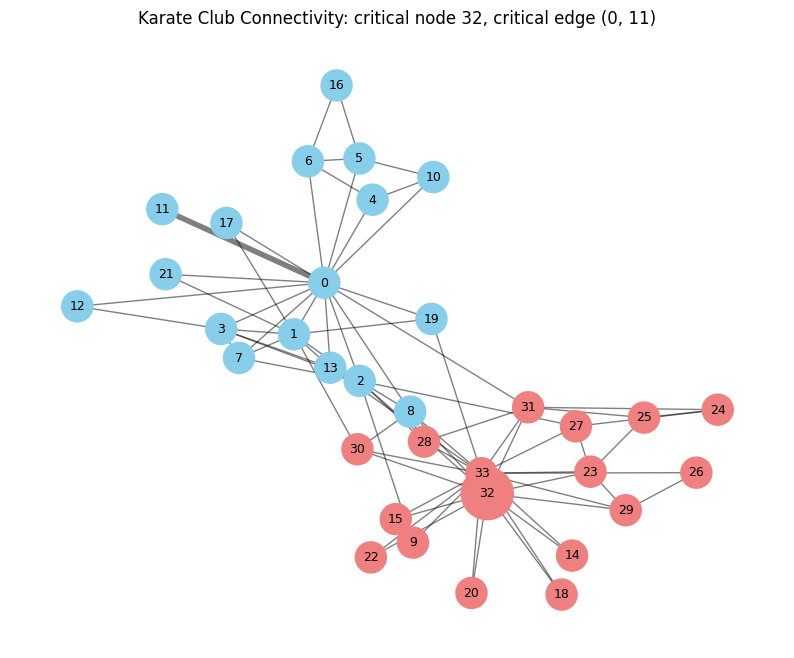

In [ ]:
pos = nx.spring_layout(G, seed=42)

node_colors = []
node_sizes = []

for n in G.nodes():
    if G.nodes[n]["club"] == "Mr. Hi":
        node_colors.append("skyblue")
    else:
        node_colors.append("lightcoral")

    if n == critical_node:
        node_sizes.append(1400)
    else:
        node_sizes.append(500)

edge_widths = []
for edge in G.edges():
    if set(edge) == set(critical_edge):
        edge_widths.append(4)
    else:
        edge_widths.append(1)

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.5)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_labels(G, pos, font_size=9)

plt.title(
    f"Karate Club Connectivity: critical node {critical_node}, critical edge {critical_edge}"
)
plt.axis("off")
plt.show()



The Karate Club network starts as one connected component containing all 34 members. This means that before removals, every member can be reached from every other member through some path. The articulation point and bridge analysis tests whether the club depends on single nodes or single relationships to remain connected. Removing the selected high-betweenness boundary node shows whether a boundary member is crucial for holding the factions together, while removing the selected critical edge tests whether one relationship alone can fragment the graph. Overall, the network has some redundancy because many members have alternative paths, but a small number of boundary or high-betweenness members still play a disproportionately important role in connecting the two sides of the club.
